In [1]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import os

In [2]:
model=VGG16(include_top=False,weights='imagenet')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
current_directory = os.getcwd()
print(f"Current Directory: {current_directory}")

Current Directory: /content


In [6]:
path="./sample_data/flower"
images=[]
#step1 and 2
features=[]
for image in os.listdir(path):
  if image[-3:]=="png":
    images.append(image)
from tensorflow.keras.preprocessing import image
i=0
for img_file in images:
    img_path = os.path.join(path, img_file)
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    feature=model.predict(img_array)
    feature_flattened = feature.flatten()
    features.append(feature_flattened)
    i+=1
    print(f"Processed: {img_file}    ",i)




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
Processed: 0026.png     1
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
Processed: 0105.png     2
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step
Processed: 0150.png     3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
Processed: 0043.png     4
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Processed: 0027.png     5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
Processed: 0126.png     6
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
Processed: 0081.png     7
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
Processed: 0075.png     8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
Processed: 0070.png     9
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
Processed: 0147.png     10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
Processed: 0201.png     11
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
Processed: 0133.png     12
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
Processed: 0161.png     13
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
Processed: 0018.png     14
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
Processed: 0058.png     15
1/1 ━━━━━━━━━━━━━━━━━━

In [7]:
features = np.array(features)
print(f"Feature shape: {features.shape}")

Feature shape: (158, 25088)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#step3
 Discuss the importance of feature extraction and why reading raw pixels is insufficient:


با استخراج کردن ویژگی ها،آن ها در وکتور هایی فشرده ذخیره میشوند و میتوان کارخوشه بندی و طبقه بندی را به صورت منظم انجام داد و پردازش ها یا الگوریتم های یادگیری ماشینبه صورت موٍثر تری کار خودشان را انجام میدهند.



In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score


kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(features)

sil_score_kmeans = silhouette_score(features, kmeans_labels)
print(f"Silhouette Score for K-Means: {sil_score_kmeans}")



/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Silhouette Score for K-Means: 0.03474212810397148


In [9]:
features

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        5.8946643],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 2.7164533,
        0.       ]], dtype=float32)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

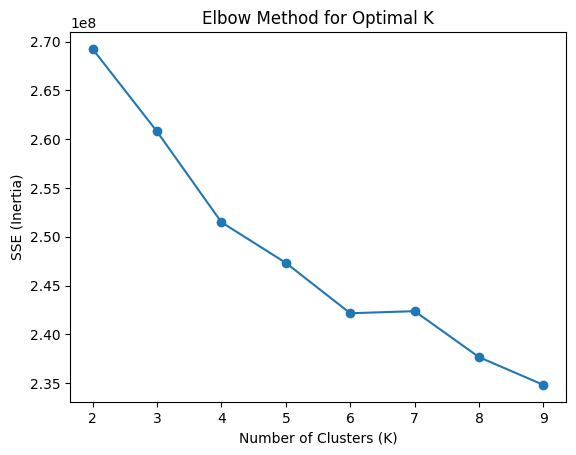

In [18]:
sse = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    sse.append(kmeans.inertia_)

plt.plot(range(2, 10), sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.show()


In [27]:

dbscan = DBSCAN(eps=0.3, min_samples=4)
dbscan_labels = dbscan.fit_predict(features)

unique_labels = set(dbscan_labels)
print(f"Number of unique clusters (including noise): {len(unique_labels)}")


Number of unique clusters (including noise): 1
